# WEB TRAFFIC ANALYTICS

##*LOAD DATA*

In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data = {
    "SessionID": [
        "SESS-5001", "SESS-5002", "SESS-5003", "SESS-5004",
        "SESS-5005", "SESS-5006", "SESS-5007", "SESS-5008",
        "SESS-5009", "SESS-5010"
    ],

    "Date": [
        "2026-06-10", "2026-06-10", "2026-06-10",
        "2026-06-11", "2026-06-11", "2026-06-11",
        "2026-06-12", "2026-06-12", "2026-06-12",
        "2026-06-12"
    ],

    "PagePath": [
        "/landing",
        "/courses",
        "/blog/python",
        "/register",
        "/pricing",
        "/landing",
        "/courses/data-science",
        "/blog/ai-trends",
        "/contact",
        "/landing"
    ],

    "Source": [
        "Google Search",
        "Direct",
        "LinkedIn",
        "Google Ads",
        "Direct",
        "Facebook",
        "Google Search",
        "Twitter",
        "Direct",
        "Google Ads"
    ],

    "DeviceCategory": [
        "Mobile",
        "Desktop",
        "Mobile",
        "Desktop",
        "Desktop",
        "Mobile",
        "Desktop",
        "Mobile",
        "Desktop",
        "Mobile"
    ],

    "SessionDurationSec": [
        145, 420, 45, 210, 60,
        15, 310, 30, 180, 290
    ],

    "PageViews": [
        3, 8, 1, 4, 2,
        1, 6, 1, 3, 5
    ],

    "Converted": [
        "Yes", "Yes", "No", "Yes", "No",
        "No", "Yes", "No", "No", "Yes"
    ],

    "BounceRate": [
        0.0, 0.0, 1.0, 0.0, 0.0,
        1.0, 0.0, 1.0, 0.0, 0.0
    ]
}

df = pd.DataFrame(data)

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

display(df)

Dataset loaded successfully!
Rows: 10
Columns: 9


,SessionID,Date,PagePath,Source,DeviceCategory,SessionDurationSec,PageViews,Converted,BounceRate
0,SESS-5001,2026-06-10,/landing,Google Search,Mobile,145,3,Yes,0.0
1,SESS-5002,2026-06-10,/courses,Direct,Desktop,420,8,Yes,0.0
2,SESS-5003,2026-06-10,/blog/python,LinkedIn,Mobile,45,1,No,1.0
3,SESS-5004,2026-06-11,/register,Google Ads,Desktop,210,4,Yes,0.0
4,SESS-5005,2026-06-11,/pricing,Direct,Desktop,60,2,No,0.0
5,SESS-5006,2026-06-11,/landing,Facebook,Mobile,15,1,No,1.0
6,SESS-5007,2026-06-12,/courses/data-science,Google Search,Desktop,310,6,Yes,0.0
7,SESS-5008,2026-06-12,/blog/ai-trends,Twitter,Mobile,30,1,No,1.0
8,SESS-5009,2026-06-12,/contact,Direct,Desktop,180,3,No,0.0
9,SESS-5010,2026-06-12,/landing,Google Ads,Mobile,290,5,Yes,0.0


## *DATA CLEANING*

In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
SessionID             0
Date                  0
PagePath              0
Source                0
DeviceCategory        0
SessionDurationSec    0
PageViews             0
Converted             0
BounceRate            0
dtype: int64

Duplicate rows:
0

Data types:
SessionID                     object
Date                  datetime64[ns]
PagePath                      object
Source                        object
DeviceCategory                object
SessionDurationSec             int64
PageViews                      int64
Converted                     object
BounceRate                   float64
dtype: object


## *TRAFFIC CHANNEL*

In [4]:
channel_map = {
    "Google Search": "Organic",
    "Google Ads": "Ads",
    "Direct": "Direct",
    "LinkedIn": "Social",
    "Facebook": "Social",
    "Twitter": "Social"
}

df["Channel"] = df["Source"].map(channel_map)

print("Traffic channel added:")
display(df[["Source", "Channel"]])

Traffic channel added:


,Source,Channel
0,Google Search,Organic
1,Direct,Direct
2,LinkedIn,Social
3,Google Ads,Ads
4,Direct,Direct
5,Facebook,Social
6,Google Search,Organic
7,Twitter,Social
8,Direct,Direct
9,Google Ads,Ads


## *OVERALL KPIs*

In [5]:
total_sessions = len(df)

# Number of sessions with BounceRate = 1
bounced_sessions = (df["BounceRate"] == 1).sum()

overall_bounce_rate = (
    bounced_sessions / total_sessions
) * 100

# Average session duration
avg_session_duration = df["SessionDurationSec"].mean()

# Average pageviews
avg_pageviews = df["PageViews"].mean()

# Number of conversions
conversions = (df["Converted"] == "Yes").sum()

# Overall conversion rate
conversion_rate = (
    conversions / total_sessions
) * 100

print("========== OVERALL KPIs ==========")

print(f"Total Sessions        : {total_sessions}")
print(f"Bounced Sessions      : {bounced_sessions}")
print(f"Overall Bounce Rate   : {overall_bounce_rate:.1f}%")

print(f"Average Duration      : {avg_session_duration:.1f} seconds")
print(f"Average Pageviews     : {avg_pageviews:.1f}")

print(f"Conversions           : {conversions}")
print(f"Conversion Rate       : {conversion_rate:.1f}%")

========== OVERALL KPIs ==========
Total Sessions        : 10
Bounced Sessions      : 3
Overall Bounce Rate   : 30.0%
Average Duration      : 170.5 seconds
Average Pageviews     : 3.4
Conversions           : 5
Conversion Rate       : 50.0%


## *DEVICE COHORT ANALYSIS*

In [6]:
device_analysis = (
    df.groupby("DeviceCategory")
      .agg(
          Sessions=("SessionID", "count"),
          Bounce_Rate=("BounceRate", "mean"),
          Avg_Duration=("SessionDurationSec", "mean"),
          Avg_Pageviews=("PageViews", "mean")
      )
      .reset_index()
)

# Convert bounce rate to percentage
device_analysis["Bounce_Rate"] = (
    device_analysis["Bounce_Rate"] * 100
)

device_analysis["Avg_Duration"] = (
    device_analysis["Avg_Duration"].round(1)
)

device_analysis["Avg_Pageviews"] = (
    device_analysis["Avg_Pageviews"].round(2)
)

print("========== DEVICE COHORT ANALYSIS ==========")

display(device_analysis)

========== DEVICE COHORT ANALYSIS ==========


,DeviceCategory,Sessions,Bounce_Rate,Avg_Duration,Avg_Pageviews
0,Desktop,5,0.0,236.0,4.6
1,Mobile,5,60.0,105.0,2.2


## *TRAFFIC MIX*

In [7]:
traffic_mix = (
    df["Channel"]
    .value_counts()
    .reindex(["Organic", "Ads", "Direct", "Social"])
    .fillna(0)
    .astype(int)
    .reset_index()
)

traffic_mix.columns = ["Channel", "Sessions"]

traffic_mix["Percentage"] = (
    traffic_mix["Sessions"] / total_sessions * 100
).round(1)

print("========== TRAFFIC MIX ==========")

display(traffic_mix)

========== TRAFFIC MIX ==========


,Channel,Sessions,Percentage
0,Organic,2,20.0
1,Ads,2,20.0
2,Direct,3,30.0
3,Social,3,30.0


## *CONVERSION PERFORMANCE BY CHANNEL*

In [8]:
channel_analysis = (
    df.groupby("Channel")
      .agg(
          Sessions=("SessionID", "count"),
          Conversions=("Converted",
                       lambda x: (x == "Yes").sum()),
          Bounce_Rate=("BounceRate", "mean"),
          Avg_Duration=("SessionDurationSec", "mean")
      )
      .reindex(["Organic", "Ads", "Direct", "Social"])
      .reset_index()
)

# Conversion rate
channel_analysis["Conversion_Rate"] = (
    channel_analysis["Conversions"]
    / channel_analysis["Sessions"]
    * 100
)

# Bounce rate percentage
channel_analysis["Bounce_Rate"] = (
    channel_analysis["Bounce_Rate"] * 100
)

channel_analysis["Conversion_Rate"] = (
    channel_analysis["Conversion_Rate"].round(1)
)

channel_analysis["Bounce_Rate"] = (
    channel_analysis["Bounce_Rate"].round(1)
)

channel_analysis["Avg_Duration"] = (
    channel_analysis["Avg_Duration"].round(1)
)

print("========== CHANNEL PERFORMANCE ==========")

display(channel_analysis)

========== CHANNEL PERFORMANCE ==========


,Channel,Sessions,Conversions,Bounce_Rate,Avg_Duration,Conversion_Rate
0,Organic,2,2,0.0,227.5,100.0
1,Ads,2,2,0.0,250.0,100.0
2,Direct,3,1,0.0,220.0,33.3
3,Social,3,0,100.0,30.0,0.0


## *PAGE-LEVEL DROP-OFF ANALYSIS*

In [9]:
page_analysis = (
    df.groupby("PagePath")
      .agg(
          Sessions=("SessionID", "count"),
          Conversions=("Converted",
                       lambda x: (x == "Yes").sum())
      )
      .reset_index()
)

# Calculate drop-off rate
page_analysis["Dropoff_Rate"] = (
    (page_analysis["Sessions"] -
     page_analysis["Conversions"])
    / page_analysis["Sessions"]
    * 100
)

# Sort highest drop-off first
page_analysis = (
    page_analysis
    .sort_values("Dropoff_Rate", ascending=False)
    .reset_index(drop=True)
)

page_analysis["Dropoff_Rate"] = (
    page_analysis["Dropoff_Rate"].round(1)
)

print("========== PAGE-LEVEL DROP-OFF ==========")

display(page_analysis)

========== PAGE-LEVEL DROP-OFF ==========


,PagePath,Sessions,Conversions,Dropoff_Rate
0,/blog/ai-trends,1,0,100.0
1,/blog/python,1,0,100.0
2,/contact,1,0,100.0
3,/pricing,1,0,100.0
4,/landing,3,2,33.3
5,/courses,1,1,0.0
6,/courses/data-science,1,1,0.0
7,/register,1,1,0.0


## *DROP-OFF STATUS*

In [10]:
def get_status(rate):

    if rate >= 75:
        return "High"

    elif rate >= 25:
        return "Moderate"

    else:
        return "Low"


page_analysis["Status"] = (
    page_analysis["Dropoff_Rate"]
    .apply(get_status)
)

display(page_analysis)

,PagePath,Sessions,Conversions,Dropoff_Rate,Status
0,/blog/ai-trends,1,0,100.0,High
1,/blog/python,1,0,100.0,High
2,/contact,1,0,100.0,High
3,/pricing,1,0,100.0,High
4,/landing,3,2,33.3,Moderate
5,/courses,1,1,0.0,Low
6,/courses/data-science,1,1,0.0,Low
7,/register,1,1,0.0,Low


## *LANDING PAGE CALCULATION*

In [11]:

landing = df[df["PagePath"] == "/landing"]

landing_sessions = len(landing)

landing_conversions = (
    landing["Converted"] == "Yes"
).sum()

landing_conversion_rate = (
    landing_conversions /
    landing_sessions *
    100
)

landing_dropoff_rate = 100 - landing_conversion_rate

print("========== /LANDING ANALYSIS ==========")

print("Sessions:", landing_sessions)
print("Conversions:", landing_conversions)
print(f"Conversion Rate: {landing_conversion_rate:.1f}%")
print(f"Drop-off Rate: {landing_dropoff_rate:.1f}%")

========== /LANDING ANALYSIS ==========
Sessions: 3
Conversions: 2
Conversion Rate: 66.7%
Drop-off Rate: 33.3%


## *TRAFFIC MIX CHART*

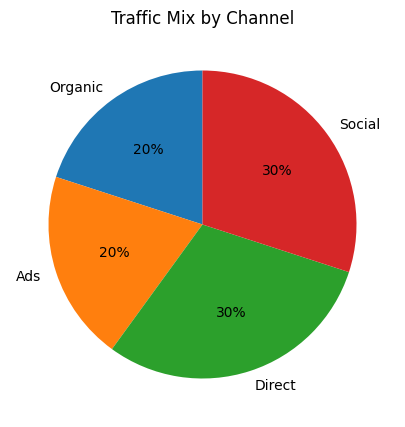

In [12]:
plt.figure(figsize=(7, 5))

plt.pie(
    traffic_mix["Sessions"],
    labels=traffic_mix["Channel"],
    autopct="%1.0f%%",
    startangle=90
)

plt.title("Traffic Mix by Channel")

plt.show()

## *DEVICE PERFORMANCE CHART*

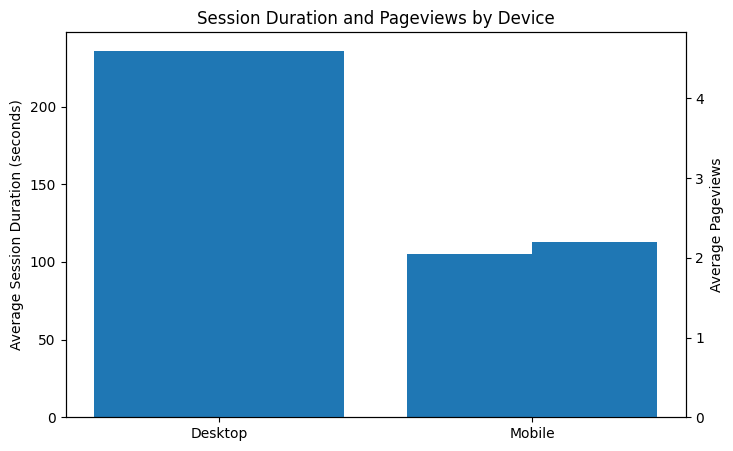

In [13]:

x = np.arange(len(device_analysis))

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.bar(
    x - 0.2,
    device_analysis["Avg_Duration"],
    width=0.4,
    label="Avg Duration (seconds)"
)

ax1.set_ylabel("Average Session Duration (seconds)")
ax1.set_xticks(x)
ax1.set_xticklabels(device_analysis["DeviceCategory"])

ax2 = ax1.twinx()

ax2.bar(
    x + 0.2,
    device_analysis["Avg_Pageviews"],
    width=0.4,
    label="Avg Pageviews"
)

ax2.set_ylabel("Average Pageviews")

plt.title("Session Duration and Pageviews by Device")

plt.show()

## *CONVERSION RATE BY CHANNEL*

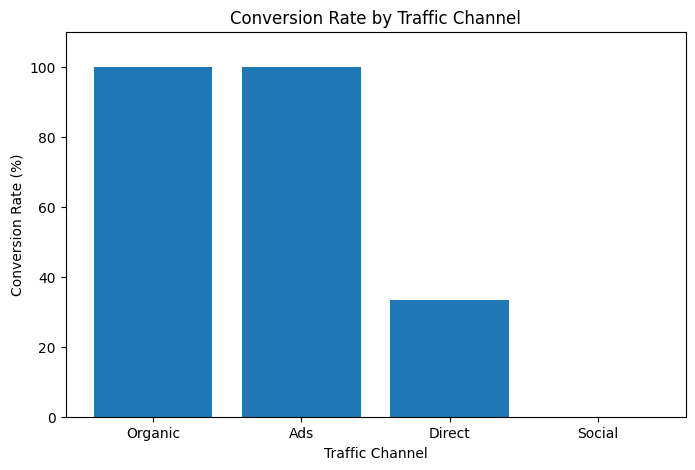

In [14]:

plt.figure(figsize=(8, 5))

plt.bar(
    channel_analysis["Channel"],
    channel_analysis["Conversion_Rate"]
)

plt.ylabel("Conversion Rate (%)")
plt.xlabel("Traffic Channel")
plt.title("Conversion Rate by Traffic Channel")

plt.ylim(0, 110)

plt.show()

## *BOUNCE RATE BY CHANNEL*

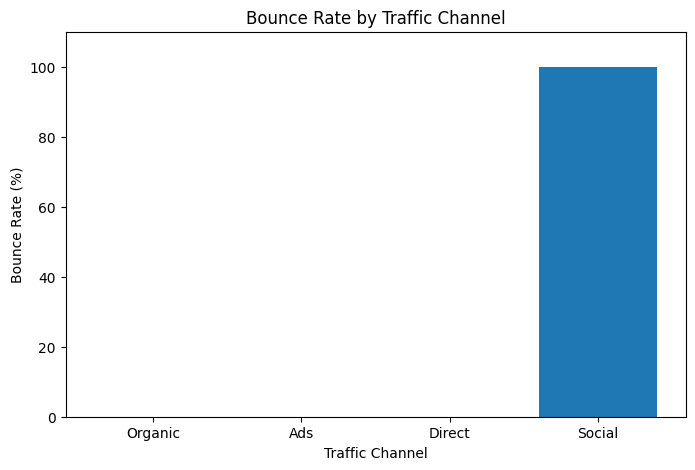

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    channel_analysis["Channel"],
    channel_analysis["Bounce_Rate"]
)

plt.ylabel("Bounce Rate (%)")
plt.xlabel("Traffic Channel")
plt.title("Bounce Rate by Traffic Channel")

plt.ylim(0, 110)

plt.show()

## *PAGE-LEVEL DROP-OFF CHART*

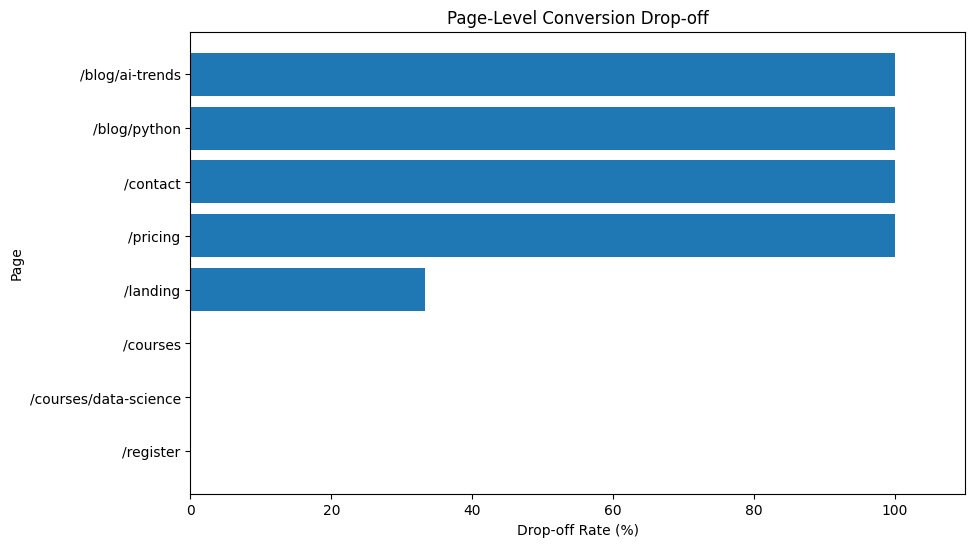

In [16]:
plt.figure(figsize=(10, 6))

plt.barh(
    page_analysis["PagePath"],
    page_analysis["Dropoff_Rate"]
)

plt.xlabel("Drop-off Rate (%)")
plt.ylabel("Page")
plt.title("Page-Level Conversion Drop-off")

plt.xlim(0, 110)

plt.gca().invert_yaxis()

plt.show()

## *FINAL SUMMARY TABLES*

In [17]:
print("\n" + "="*60)
print("FINAL WEB TRAFFIC ANALYTICS SUMMARY")
print("="*60)

print("\n1. OVERALL KPIs")
print("-"*40)

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Sessions",
        "Bounced Sessions",
        "Overall Bounce Rate",
        "Average Session Duration (sec)",
        "Average Pageviews / Session",
        "Total Conversions",
        "Overall Conversion Rate"
    ],

    "Value": [
        total_sessions,
        bounced_sessions,
        f"{overall_bounce_rate:.1f}%",
        f"{avg_session_duration:.1f}",
        f"{avg_pageviews:.1f}",
        conversions,
        f"{conversion_rate:.1f}%"
    ]
})

display(kpi_summary)


print("\n2. DEVICE PERFORMANCE")
print("-"*40)

display(device_analysis)


print("\n3. CHANNEL PERFORMANCE")
print("-"*40)

display(channel_analysis)


print("\n4. PAGE-LEVEL DROP-OFF")
print("-"*40)

display(page_analysis)


FINAL WEB TRAFFIC ANALYTICS SUMMARY

1. OVERALL KPIs
----------------------------------------


,Metric,Value
0,Total Sessions,10
1,Bounced Sessions,3
2,Overall Bounce Rate,30.0%
3,Average Session Duration (sec),170.5
4,Average Pageviews / Session,3.4
5,Total Conversions,5
6,Overall Conversion Rate,50.0%



2. DEVICE PERFORMANCE
----------------------------------------


,DeviceCategory,Sessions,Bounce_Rate,Avg_Duration,Avg_Pageviews
0,Desktop,5,0.0,236.0,4.6
1,Mobile,5,60.0,105.0,2.2



3. CHANNEL PERFORMANCE
----------------------------------------


,Channel,Sessions,Conversions,Bounce_Rate,Avg_Duration,Conversion_Rate
0,Organic,2,2,0.0,227.5,100.0
1,Ads,2,2,0.0,250.0,100.0
2,Direct,3,1,0.0,220.0,33.3
3,Social,3,0,100.0,30.0,0.0



4. PAGE-LEVEL DROP-OFF
----------------------------------------


,PagePath,Sessions,Conversions,Dropoff_Rate,Status
0,/blog/ai-trends,1,0,100.0,High
1,/blog/python,1,0,100.0,High
2,/contact,1,0,100.0,High
3,/pricing,1,0,100.0,High
4,/landing,3,2,33.3,Moderate
5,/courses,1,1,0.0,Low
6,/courses/data-science,1,1,0.0,Low
7,/register,1,1,0.0,Low


## *ANALYSIS RESULTS*

In [18]:
kpi_summary.to_csv(
    "overall_kpis.csv",
    index=False
)

device_analysis.to_csv(
    "device_analysis.csv",
    index=False
)

traffic_mix.to_csv(
    "traffic_mix.csv",
    index=False
)

channel_analysis.to_csv(
    "channel_analysis.csv",
    index=False
)

page_analysis.to_csv(
    "page_dropoff_analysis.csv",
    index=False
)

print("All analysis files exported successfully!")

All analysis files exported successfully!
